# LSA (Latent Semantic Analysis) Recommender
After building the TF-IDF baseline, I extended the recommender with **Latent Semantic Analysis (LSA)** using **Truncated SVD**. The idea is to start from the same TF-IDF matrix, but then reduce that sparse high-dimensional representation into a smaller latent space.

Now the definition of similarity changes. In the TF-IDF baseline, songs are similar when they share many of the same distinctive words or phrases. In the LSA model, songs are similar when they occupy nearby positions in a lower dimensional semantic space shaped by broader word co-occurrence patterns across the corpus.

We can then capture songs expressing similar themes without using the exact same vocabulary. By compressing the TF-IDF matrix into latent dimensions, LSA can capture relationships that are not always visible through direct lexical overlap alone.


## 1. Imports & Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

from lsa_recommender import (
    build_lsa_recommender,
    recommend_songs,
    get_top_topics,
    get_song_top_topics
)
# Import TF-IDF recommender for direct side-by-side comparison
from tfidf_recommender import (
    build_tfidf_recommender,
    recommend_songs as tfidf_recommend
)

pd.set_option('display.max_colwidth', 60)

## 2. Recommenders

In [2]:
LYRICS_PATH = '../data/processed/lyrics_clean.csv'
N_COMPONENTS = 100  # number of latent topics - to be experimented with below

# LSA
lyrics_df, lsa_matrix, lsa_sim, svd, vectorizer = build_lsa_recommender(
    LYRICS_PATH, n_components=N_COMPONENTS
)

# TF-IDF baseline
_, tfidf_matrix, tfidf_sim = build_tfidf_recommender(LYRICS_PATH)

print(f'Songs:              {len(lyrics_df)}')
print(f'TF-IDF matrix:      {tfidf_matrix.shape}  (songs x vocab terms)')
print(f'LSA matrix:         {lsa_matrix.shape}   (songs x latent topics)')
print(f'Explained variance: {svd.explained_variance_ratio_.sum():.1%} of total variance captured in {N_COMPONENTS} components')

Songs:              1502
TF-IDF matrix:      (1502, 10000)  (songs x vocab terms)
LSA matrix:         (1502, 100)   (songs x latent topics)
Explained variance: 22.4% of total variance captured in 100 components


The original TF-IDF matrix has shape **(1502, 10000)**, meaning that 1,502 songs are represented across 10,000 vocabulary features. After applying Truncated SVD with **100 components**, the representation is reduced to an **LSA matrix of shape (1502, 100)**.

This reduced representation captures approximately **22.4% of the total variance** in the original TF-IDF space. While that means some information is compressed away, the tradeoff is that the model can focus on broader latent structure instead of isolated  overlap between words alone. The LSA recommender is designed to sacrifice some surface detail in exchange for a more general semantic representation of lyrical similarity.

## 3. Inspecting the Latent Topics
Each component is defined by terms that tend to co-occur across songs, allowing the model to group together songs that may share themes, moods, or narrative structure even when their exact wording differs. Inspecting the highest weighted terms in each component helps show what kinds of lyrical patterns the recommender is learning from the corpus.

In [3]:
topics_df = get_top_topics(svd, vectorizer, n_topics=20, n_terms=8)
print("Top 8 terms per latent topic:\n")
topics_df

Top 8 terms per latent topic:



,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,im,la,ooh,yeah,oh,dont,love,oh,im,hey,que,hey,know,want,feel,da,ive,da,ill,ill
1,dont,la la,ooh ooh,yeah yeah,yeah,know,baby,oh oh,baby,hey hey,im,wanna,know know,want want,like,want,time,doo,world,shes
2,know,que,yeah,nigga,oh oh,wanna,dont,baby,hey,que,el,hey hey,love,im,feel like,doo,got,come,wanna,tonight
3,like,ooh,oh,like,yeah yeah,dont know,want,im,hey hey,know,te,dont wanna,hey,love,just,gonna,want,feel,want,wait
4,just,el,yeah yeah,bitch,baby,dont wanna,love love,nigga,la la,baby,love,dont,shes,youre,wanna,da da,ive got,da da,away,just
5,love,doo,oh oh,got,wanna,know know,hey,bitch,gonna,want,en,im,hey hey,dont want,shes,wanna,feel,like,know know,youre
6,oh,en,love,im,dont,im,baby baby,got,im gonna,know know,lo,ill,dont know,oh,baby,doo doo,wanna,away,dont wanna,girl
7,yeah,ooh ooh,ah,fuck,know,want,wanna,like,yeah,el,mi,oh oh,like,ha,dream,youre,want want,doo doo,know,let


There is a ton of overlap in these topics, consisting heavily of adlibs and repreated phrases. This might be a good argument songs being better represented by musical similairty than lyrical, but that is a biased assumption because of the confines my dataset exhibits. I'm seeing a lot of similarities around the theme of love and making love... It also appears that the adlib heavy hip-hop songs are dominating these topics. 

## Scree Plot for Choosing n-components 
How much variance does each additional component add? The "elbow" in this plot is a natural stopping point.

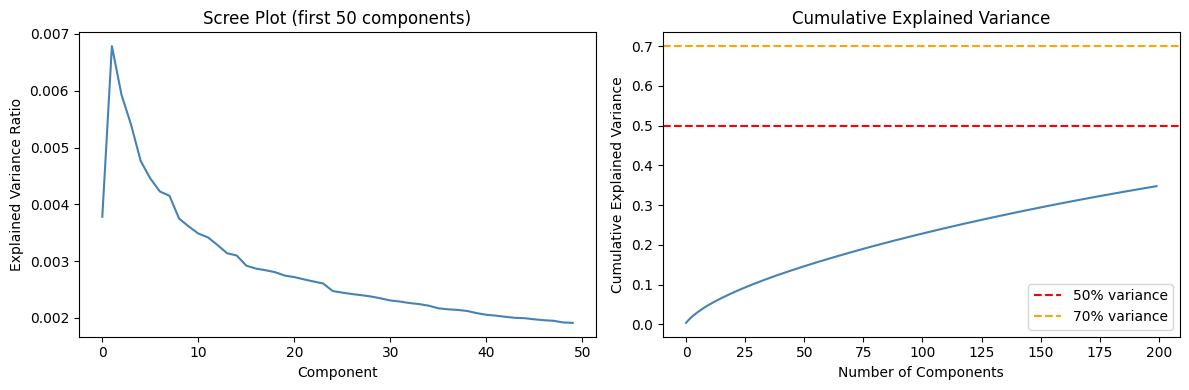

30% variance captured at 156 components
50% variance captured at 1 components
70% variance captured at 1 components


In [3]:
vec_inspect = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
tfidf_inspect = vec_inspect.fit_transform(lyrics_df['processed_lyrics'])

svd_inspect = TruncatedSVD(n_components=200, random_state=42)
svd_inspect.fit(tfidf_inspect)

cumvar = svd_inspect.explained_variance_ratio_.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(svd_inspect.explained_variance_ratio_[:50], color='steelblue')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (first 50 components)')

axes[1].plot(cumvar, color='steelblue')
axes[1].axhline(0.5, color='red', linestyle='--', label='50% variance')
axes[1].axhline(0.7, color='orange', linestyle='--', label='70% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

for threshold in [0.3, 0.5, 0.7]:
    n = (cumvar >= threshold).argmax() + 1
    print(f'{threshold:.0%} variance captured at {n} components')


50% and 70% of variance is captured by one component. My hypothesis that adlib heavy hip-hop songs are dominating that topic space could be supported by this result.

## Side-by-Side Recommendations

In [4]:
def compare_models(seed_title, seed_artist=None, k=10):
    """Print TF-IDF and LSA recommendations side by side for a seed song."""
    tfidf_recs = tfidf_recommend(
        lyrics_df, tfidf_sim, seed_title=seed_title, seed_artist=seed_artist, k=k
    ).rename(columns={"similarity": "tfidf_score"})

    lsa_recs = recommend_songs(
        lyrics_df, lsa_sim, seed_title=seed_title, seed_artist=seed_artist, k=k
    ).rename(columns={"similarity": "lsa_score"})

    tfidf_recs.index += 1
    lsa_recs.index += 1

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print(f"{'Rank':<5} {'── TF-IDF ──':<45} {'── LSA ──':<45}")
    print('-' * 95)
    for i in range(1, k + 1):
        t = tfidf_recs.loc[i]
        l = lsa_recs.loc[i]
        t_str = f"{t['track_name'][:28]} — {t['artist'][:14]} ({t['tfidf_score']:.3f})"
        l_str = f"{l['track_name'][:28]} — {l['artist'][:14]} ({l['lsa_score']:.3f})"
        print(f"{i:<5} {t_str:<45} {l_str:<45}")

    return tfidf_recs, lsa_recs

In [5]:
# --- Grunge ---
tfidf_grunge, lsa_grunge = compare_models('Iron Clad Lou', seed_artist='Hum')


Seed: 'Iron Clad Lou' by Hum
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Stand up and Win — Spymob (0.144)             muscles — not dvr (0.517)                    
2     Never Lonely — Space Mountain (0.135)         Never Lonely — Space Mountain (0.504)        
3     Downtown — Varsity (0.123)                    Wake up Jacob — Sitcom (0.504)               
4     Rain — World's Experi (0.119)                 Lonely Mess — Laundry (0.501)                
5     Faxing It In — Smushie (0.112)                Hell N Back — Bakar (0.488)                  
6     Hippies — flipturn (0.109)                    Stadium Arcadium — Red Hot Chili  (0.478)    
7     Warmest Part of the Winter — Voxtrot (0.106)  Motorola — Miloe (0.465)                     
8     2023 — Blue Rain Boot (0.105)                 November — Psychedelic Po (0.449)     

The LSA recommender has much higher similarity scores compared to TF-IDF alone. Still, the LSA reommender didn't rank a single grunge song in the top-10, further supporting the argument that grunge music is best represented through its hardcore rock sound. 

In [6]:
# --- Soul ---
tfidf_soul, lsa_soul = compare_models("Can I Help You?", seed_artist='Amnesty')


Seed: 'Can I Help You?' by Amnesty
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Sweetest Thing on This Side  — Papa Bear & Hi (0.307) Sweetest Thing on This Side  — Papa Bear & Hi (0.489)
2     Chicago — Michael Jackso (0.171)              Lean on Me — Bill Withers (0.463)            
3     Bailee — The Licks (0.161)                    Wizard Of Finance — Parliament (0.447)       
4     Wizard Of Finance — Parliament (0.149)        Some Are Lakes — Land of Talk (0.434)        
5     Cause = Time — Broken Social  (0.144)         Chicago — Michael Jackso (0.413)             
6     Mystery Girl — Housecall (0.123)              Need — Mustard Servic (0.405)                
7     Ellie — Make Friends (0.118)                  Blue And Sentimental — Oscar Peterson (0.403)
8     Hard To Handle — The Black Crow (0.098)       Simulation — Rep

Again, the LSA recommender his showing significantly higher similarity scores. Additionally, it ranked 3 soul songs in the top-10; one better than the TF-IDF model. 

In [7]:
# --- Latin ---
tfidf_latin, lsa_latin = compare_models(
    'Los Libros de la Buena Memoria', seed_artist='Invisible'
)


Seed: 'Los Libros de la Buena Memoria' by Invisible
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     SMUCKERS (feat. Lil Wayne &  — Tyler, The Cre (0.497) La Balsa — Los Gatos (0.973)                 
2     Las Habladurias del Mundo — Pescado Rabios (0.458) Oh Qué Será? — Willie Colón (0.968)          
3     After The Storm (feat. Tyler — Kali Uchis (0.445) SMUCKERS (feat. Lil Wayne &  — Tyler, The Cre (0.966)
4     Como Mata el Viento Norte — La Maquina De  (0.427) Elementales Leches — Invisible (0.965)       
5     Oh Qué Será? — Willie Colón (0.421)           Como Mata el Viento Norte — La Maquina De  (0.964)
6     Promesas Sobre El Bidet — Charly García (0.364) Danger (Spider) (Offset & JI — Offset (0.959)
7     ･－･･ ･ － ･･ － －－･ －－－ — ･ ･－･ ･－ ･･･ ･ (0.358) Las Habladurias del Mundo — Pescado Rabios (0.957)
8     Elementales Leches

For latin music, the LSA model shows extremely high similarity scores. I expected this because my corpus of songs doesn't have many latin songs compared to other genres and the simple fact of them all being songs in spanish or portugese should make it easy for the LSA to accurate identify that as a topic. Seven out of the top-10 most similar songs were latin in the LSA model compared to only 6 in the TF-IDF model. Not much of a difference on that front, however, the similarity scores are much higher indicating the LSA recommender has a lot more confidence in this genre. It is also important to note that a few hip-hop songs are present in both top-10 rankings. This is most likely due to adlibs being confused for latin words. 

In [8]:
# --- Hip-hop ---
tfidf_hiphop, lsa_hiphop = compare_models('House Money', seed_artist='Baby Keem')


Seed: 'House Money' by Baby Keem
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Jesus Is The One (I Got Depr — Zack Fox (0.441) Jesus Is The One (I Got Depr — Zack Fox (0.899)
2     Can You Rap Like Me? — Trippie Redd (0.363)   Can You Rap Like Me? — Trippie Redd (0.834)  
3     Hit Bout It — Lil Yachty (0.329)              trademark usa — Baby Keem (0.818)            
4     Blood On Me — Sampha (0.321)                  REEL IT IN — Aminé (0.812)                   
5     REEL IT IN — Aminé (0.286)                    CORSO — Tyler, The Cre (0.801)               
6     trademark usa — Baby Keem (0.272)             Hit Bout It — Lil Yachty (0.787)             
7     JayJay-Z — Zelooperz (0.266)                  JayJay-Z — Zelooperz (0.756)                 
8     Fresh Prince Of Utah — YoungBoy Never (0.262) Fresh Prince Of Utah — YoungBo

Further proving the LSA model's strength, the hip-hop similarity scores are significantly higher than those of TF-IDF. However, both top-10 lists are exclusively hip-hop which has been consistent across all tests. The signficantly higher similarity scores could be due to the dominating adlib topics I discussed previously. 

## Overlap Analysis

In [9]:
def overlap_stats(tfidf_recs, lsa_recs, label):
    tfidf_set = set(zip(tfidf_recs['track_name'], tfidf_recs['artist']))
    lsa_set   = set(zip(lsa_recs['track_name'],   lsa_recs['artist']))
    shared    = tfidf_set & lsa_set
    jaccard   = len(shared) / len(tfidf_set | lsa_set)
    print(f"{label}")
    print(f"  Shared songs:    {len(shared)}/10")
    print(f"  Jaccard score:   {jaccard:.2f}")
    if shared:
        print(f"  Overlap:         {', '.join([s[0] for s in shared])}")
    print()

overlap_stats(tfidf_grunge,  lsa_grunge,  'Grunge  (Iron Clad Lou)')
overlap_stats(tfidf_soul,    lsa_soul,    'Soul    (Can I Help You?)')
overlap_stats(tfidf_latin,   lsa_latin,   'Latin   (Los Libros...)')
overlap_stats(tfidf_hiphop,  lsa_hiphop,  'Hip-hop (House Money)')

Grunge  (Iron Clad Lou)
  Shared songs:    1/10
  Jaccard score:   0.05
  Overlap:         Never Lonely

Soul    (Can I Help You?)
  Shared songs:    4/10
  Jaccard score:   0.25
  Overlap:         Sweetest Thing on This Side of Heaven, Chicago, Wizard Of Finance, Cause = Time

Latin   (Los Libros...)
  Shared songs:    7/10
  Jaccard score:   0.54
  Overlap:         Oh Qué Será?, Como Mata el Viento Norte, La Balsa, SMUCKERS (feat. Lil Wayne & Kanye West), Elementales Leches, Las Habladurias del Mundo, After The Storm (feat. Tyler, The Creator & Bootsy Collins)

Hip-hop (House Money)
  Shared songs:    8/10
  Jaccard score:   0.67
  Overlap:         CORSO, Hit Bout It, REEL IT IN, Fresh Prince Of Utah, Can You Rap Like Me?, JayJay-Z, trademark usa, Jesus Is The One (I Got Depression)



Still, no model is doing well with grunge music, however these are by for this highest overlap/similarity scores seen by any model so far. Clearly using LSA to categorize songs by topics imitating lyrical similarity across genres is working quite well. 

## N-components Test

In [10]:
results_by_k = {}
for n in [50, 100, 200]:
    _, _, sim_n, _, _ = build_lsa_recommender(LYRICS_PATH, n_components=n)
    recs = recommend_songs(lyrics_df, sim_n, 'House Money', 'Baby Keem', k=10)
    results_by_k[n] = set(zip(recs['track_name'], recs['artist']))
    print(f"n={n}: {list(recs['track_name'])[:5]}")

print(f"\nOverlap 50 vs 100:  {len(results_by_k[50]  & results_by_k[100])}/10")
print(f"Overlap 100 vs 200: {len(results_by_k[100] & results_by_k[200])}/10")
print(f"Overlap 50 vs 200:  {len(results_by_k[50]  & results_by_k[200])}/10")

n=50: ['Jesus Is The One (I Got Depression)', 'Hit Bout It', 'CORSO', 'trademark usa', 'REEL IT IN']
n=100: ['Jesus Is The One (I Got Depression)', 'Can You Rap Like Me?', 'trademark usa', 'REEL IT IN', 'CORSO']
n=200: ['Jesus Is The One (I Got Depression)', 'Can You Rap Like Me?', 'REEL IT IN', 'trademark usa', 'Hit Bout It']

Overlap 50 vs 100:  8/10
Overlap 100 vs 200: 9/10
Overlap 50 vs 200:  7/10


I don't fully get these results. 

## Similarity Score Distribution: LSA vs TF-IDF

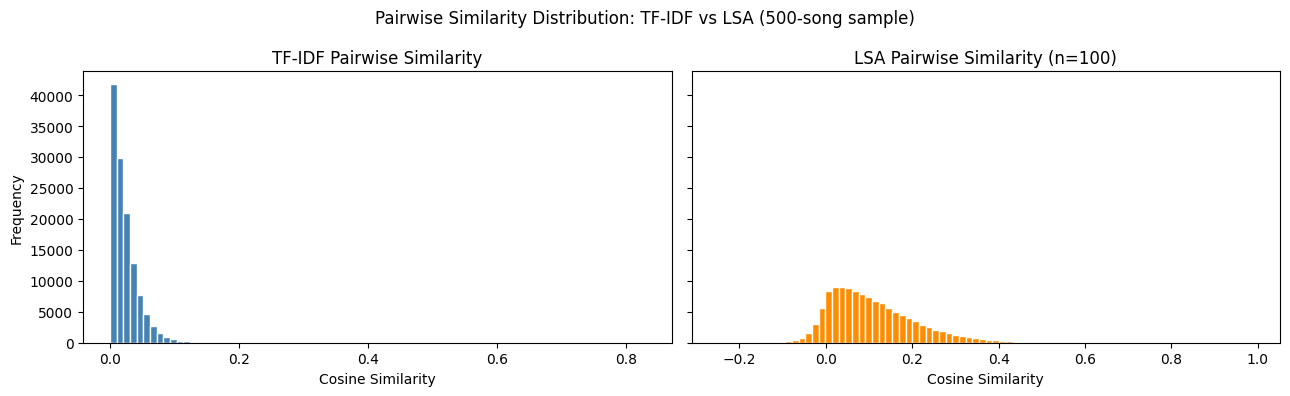

TF-IDF:  mean=0.0233  median=0.0172  >0.1: 1.2%  >0.3: 0.1%
LSA:  mean=0.1099  median=0.0896  >0.1: 45.9%  >0.3: 5.4%


In [11]:
sample_size = 500
rng = np.random.default_rng(42)
idx = rng.choice(len(lyrics_df), size=sample_size, replace=False)

lsa_sample   = lsa_sim[np.ix_(idx, idx)]
tfidf_sample = tfidf_sim[np.ix_(idx, idx)]

lsa_upper   = lsa_sample[np.triu_indices(sample_size, k=1)]
tfidf_upper = tfidf_sample[np.triu_indices(sample_size, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].hist(tfidf_upper, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(lsa_upper, bins=80, color='darkorange', edgecolor='white')
axes[1].set_title(f'LSA Pairwise Similarity (n={N_COMPONENTS})')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution: TF-IDF vs LSA (500-song sample)')
plt.tight_layout()
plt.show()

for label, arr in [('TF-IDF', tfidf_upper), ('LSA', lsa_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.1: {(arr > 0.1).mean()*100:.1f}%  >0.3: {(arr > 0.3).mean()*100:.1f}%")

LSA scores are much higher on average and more normally distributed. TF-IDF scores cluster near zero because exact vocabulary overlap is rare. This distribution shift is one reason LSA sometimes produces better recommendatons - it can find connections TF-IDF misses - but also why it can over connected unrelated songs. 

## Dominant Topics Per Seed Song

In [12]:
seeds = [
    ('Iron Clad Lou',                 'Hum'),
    ("Can I Help You?",               'Amnesty'),
    ('Los Libros de la Buena Memoria','Invisible'),
    ('House Money',                   'Baby Keem'),
]

for title, artist in seeds:
    try:
        topic_scores = get_song_top_topics(
            lyrics_df, lsa_matrix, title, seed_artist=artist, n_topics=5
        )
        print(f"'{title}' — dominant topics:")
        print(topic_scores.to_string())
        print()
    except ValueError as e:
        print(f"[NOT FOUND] {e}\n")

'Iron Clad Lou' — dominant topics:
Topic 1     0.4066
Topic 32    0.2457
Topic 79    0.2036
Topic 88    0.1914
Topic 80   -0.1797

'Can I Help You?' — dominant topics:
Topic 44   -0.2933
Topic 85   -0.2521
Topic 1     0.2402
Topic 55   -0.2233
Topic 26    0.2122

'Los Libros de la Buena Memoria' — dominant topics:
Topic 11    0.6511
Topic 2     0.5081
Topic 12   -0.3827
Topic 13   -0.1577
Topic 14   -0.1384

'House Money' — dominant topics:
Topic 4     0.4807
Topic 1     0.3820
Topic 8     0.2675
Topic 5     0.2513
Topic 31    0.1842



Topic one was the strongest in grunge by far. It includes tokens like: im, dont, know, love, oh, yeah. It has a bit of a emo feeling to it, but still not very descriptive. 
Soul music struggled with most topics it seems, which is odd to me becasue I associate soul music with some clear cultural messaging. 
Latin music is heavily dominated by topics 11 and 2 which isn't surprising because they are comprised of mainly spanish words not frequent in the rest of the corpus outside of other latin songs. Hip-hop had the most even distribution across topics which is further validating my hypothesis that adlib dominante songs are heavily influencing the topics creating by LSA. Hip-hop songs in general follow very similar pattern in both sound and lyrical messaging. They also include the most explicatives by far. 

## 10. Observations & Comparison Notes